# NCF for pinterest
<!-- 

models
- gmf
- mlp: 32 -> 16 -> 8
- neumf: gmf + mlp

exp setting
- activation: relu
- loss: log loss
- mlp init: gaussian(0, 0.01), adam
- neulml init: mlp, gmf pre-trained, sgd
- metrics: HR@10, NDCG@10
- model selection: leave-one-out
- negative sampling  -->

In [1]:
import os, sys, bson

import numpy as np
import pandas as pd
from tqdm import tqdm

import tensorflow as tf

sys.path.insert(0, '..')
from evaluate import ndcg, hr

2023-08-07 12:06:00.591803: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-08-07 12:06:00.703527: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-08-07 12:06:00.738926: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-08-07 12:06:01.328932: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

In [2]:
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
tf.config.get_visible_devices()

2023-08-07 12:06:02.949208: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-07 12:06:02.980727: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-07 12:06:02.980972: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Data Load 

In [3]:
pinterest_ncf_dir = '../../neural_collaborative_filtering/Data/'

In [4]:
test_negative_df = pd.read_csv(os.path.join(
    pinterest_ncf_dir, 'pinterest-20.test.negative'), sep='\t', header=None)
print(test_negative_df.shape)
test_negative_df.head()

(55187, 100)


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,"(0,1)",2670,8388,5861,5089,3480,8811,7193,8609,157,...,9026,7500,2704,76,4327,6263,5282,4737,6826,2357
1,"(1,25)",4356,4583,8106,4673,4485,3465,1339,3622,7494,...,5514,5499,1793,9750,5601,4601,9530,704,4955,1249
2,"(2,44)",6903,7880,2175,2316,2550,9796,3948,1353,2420,...,3620,6111,1523,1564,8213,7668,6251,8619,8,7212
3,"(3,66)",3864,662,4327,7404,7764,8957,1617,7475,2771,...,4915,6005,2517,6661,62,1697,7147,4568,5141,6558
4,"(4,94)",6471,5578,2198,2286,7429,4957,3566,7629,293,...,5317,3721,1214,4900,6535,3483,6089,6897,6025,1248


In [5]:
test_positive_df = pd.read_csv(os.path.join(
    pinterest_ncf_dir, 'pinterest-20.test.rating'), sep='\t', header=None)
print(test_positive_df.shape)
test_positive_df.head()

(55187, 4)


,0,1,2,3
0,0,1,1,0
1,1,25,1,0
2,2,44,1,0
3,3,66,1,0
4,4,94,1,0


In [6]:
train_positive_df = pd.read_csv(os.path.join(
    pinterest_ncf_dir, 'pinterest-20.train.rating'), sep='\t', header=None)
print(train_positive_df.shape)
train_positive_df.head()

(1445622, 4)


,0,1,2,3
0,0,2,1,0
1,0,3,1,0
2,0,4,1,0
3,0,5,1,0
4,0,6,1,0


# Prepare Data sets for train/test

In [7]:
train_positive_df.iloc[:, 2] = 1
train_positive = train_positive_df.iloc[:, [0,1,2]].values
train_positive.shape

(1445622, 3)

In [8]:
test_data = []

# negative
test_negative = []
for i, row in test_negative_df.iloc[:, 1:].iterrows():
    test_negative.extend([[i,item,0] for item in row])

# positive
test_positive_df.iloc[:, 2] = 1
test_positive = test_positive_df.iloc[:, [0,1,2]].values

# test_data
test_data = np.concatenate([test_negative, test_positive])

# shuffle data
np.random.shuffle(test_data)

test_data.shape

(5518700, 3)

In [9]:
all_users = train_positive_df[0].unique()
all_items = train_positive_df[1].unique()

len(all_users), len(all_items)

(55187, 9911)

In [23]:
positive_map = train_positive_df.groupby(0)[1].apply(list).to_dict()
len(positive_map.keys())

55187

# GMF

## build

In [10]:
# hyperparams
learning_rate = 0.001
batch_size = 256 #128, 256, 512, 1024
epochs = 20
num_neg = 4
topn = 10
embedding_size = 8

In [11]:
def get_gmf(num_users, num_items, latent_dim):
    
    user_input = tf.keras.layers.Input(shape=1, dtype="int32")
    item_input = tf.keras.layers.Input(shape=1, dtype="int32")

    user_embedding = tf.keras.layers.Embedding(input_dim=num_users, output_dim=latent_dim, name='gmf_user_embedding',
                    embeddings_initializer='normal', input_length=1)(user_input)
    item_embedding = tf.keras.layers.Embedding(input_dim=num_items, output_dim=latent_dim, name='gmf_item_embedding',
                    embeddings_initializer='normal', input_length=1)(item_input)
    
    user_flatten = tf.keras.layers.Flatten()(user_embedding)
    item_flatten = tf.keras.layers.Flatten()(item_embedding)

    x = tf.keras.layers.Multiply()([user_flatten, item_flatten])
    x = tf.keras.layers.Dense(units=1, activation="sigmoid", name='last_layer',
        kernel_initializer='lecun_normal')(x)

    model = tf.keras.Model([user_input, item_input], x)
    return model

In [12]:
gmf_model = get_gmf(len(all_users), len(all_items), embedding_size)
gmf_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 gmf_user_embedding (Embedding)  (None, 1, 8)        441496      ['input_1[0][0]']                
                                                                                                  
 gmf_item_embedding (Embedding)  (None, 1, 8)        79288       ['input_2[0][0]']                
                                                                                              

2023-08-07 12:06:20.907954: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-08-07 12:06:20.910821: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-07 12:06:20.911050: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-07 12:06:20.911169: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so ret

In [13]:
gmf_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss="binary_crossentropy")

## training

In [26]:
# negative sampling을 위한 함수
def sampling(num_sample, all_item_list, without):
    idx = 0
    sampled = []
    while idx < num_sample:
        randint = np.random.choice(all_item_list)
        if randint in without:
            continue
        else:
            sampled.append(randint)
            idx += 1
    return sampled

In [27]:
from multiprocessing import Pool

def sample_negative(u):
    without = positive_map[u]
    return [[u, neg, 0] for neg in \
        sampling(num_neg*len(without), all_items, without)]

def prep_train_data(train_pos_array, num_neg):
    train = []

    p = Pool(30)
    ret = p.starmap_async(sample_negative, zip(list(all_users)))
    for r in ret.get():
        train.extend(r)

    # train_data
    train = np.concatenate([train, train_pos_array])
    np.random.shuffle(train)

    return train

In [28]:
loss = gmf_model.evaluate([test_data[:, 0], test_data[:, 1]], test_data[:, 2], batch_size=2048, verbose=0)
gmf_test_pred = gmf_model.predict([test_data[:, 0], test_data[:, 1]], batch_size=2048, verbose=0)

ndcg_values = ndcg.average_ndcg(test_data[:, 0], gmf_test_pred, test_data[:, 2], topn, all_users)
hr_values, hits = hr.average_hr(test_data[:, 0], gmf_test_pred, test_data[:, 2], topn, all_users)

print(f"Init! loss: {loss}, HR: {hr_values}, NDCG: {ndcg_values}")

Init! loss: 0.693143904209137, HR: 0.09851957888633192, NDCG: 0.044660163920237146


In [29]:
gmf_history = []

for iter_ in range(epochs):
    train_data = prep_train_data(train_positive, num_neg)

    history_ = gmf_model.fit(
        [train_data[:, 0], train_data[:, 1]], train_data[:, 2], epochs=1, 
        batch_size=batch_size)
    
    gmf_history.append(history_.history['loss'])
    
    loss = gmf_model.evaluate([test_data[:, 0], test_data[:, 1]], test_data[:, 2], batch_size=2048, verbose=0)
    gmf_test_pred = gmf_model.predict([test_data[:, 0], test_data[:, 1]], batch_size=2048, verbose=0)

    ndcg_values = ndcg.average_ndcg(test_data[:, 0], gmf_test_pred, test_data[:, 2], topn, all_users)
    hr_values, hits = hr.average_hr(test_data[:, 0], gmf_test_pred, test_data[:, 2], topn, all_users)

    print(f"epoch: {iter_}, loss: {loss}, HR: {hr_values}, NDCG: {ndcg_values}")

28235/28235 [==============================] - 80s 3ms/step - loss: 0.3996
epoch: 0, loss: 0.17337633669376373, HR: 0.6996937684599634, NDCG: 0.3993432909834117
28235/28235 [==============================] - 82s 3ms/step - loss: 0.2393
epoch: 1, loss: 0.14599430561065674, HR: 0.8110968162791962, NDCG: 0.48206707475060173
28235/28235 [==============================] - 83s 3ms/step - loss: 0.2089
epoch: 2, loss: 0.1339743435382843, HR: 0.8345987279612952, NDCG: 0.5046181300034811
28235/28235 [==============================] - 83s 3ms/step - loss: 0.1964
epoch: 3, loss: 0.1306954026222229, HR: 0.8445104825411782, NDCG: 0.5128031903616589
28235/28235 [==============================] - 83s 3ms/step - loss: 0.1895
epoch: 4, loss: 0.12674446403980255, HR: 0.8489318136517658, NDCG: 0.5155340184102698
28235/28235 [==============================] - 79s 3ms/step - loss: 0.1853
epoch: 5, loss: 0.12251270562410355, HR: 0.8518129269574356, NDCG: 0.5199833959010848
28235/28235 [======================

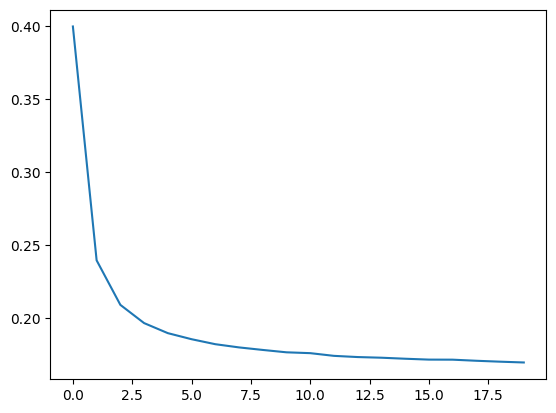

In [30]:
import matplotlib.pyplot as plt

plt.plot(gmf_history)
plt.show()

## prediction

In [31]:
gmf_test_pred = gmf_model.predict([test_data[:, 0], test_data[:, 1]], batch_size=2048)

ndcg_values = ndcg.average_ndcg(test_data[:, 0], gmf_test_pred, test_data[:, 2], topn, all_users)
hr_values, hits = hr.average_hr(test_data[:, 0], gmf_test_pred, test_data[:, 2], topn, all_users)

print(f"HR: {hr_values}, NDCG: {ndcg_values}")

2695/2695 [==============================] - 3s 1ms/step
HR: 0.8620508453077718, NDCG: 0.5316097963957579


## save weights

In [32]:
# Save the Model
gmf_model.save('../checkpoints/pinterest_gmf_model')

INFO:tensorflow:Assets written to: ../checkpoints/pinterest_gmf_model/assets


## Multi Layer Perceptron

In [33]:
def get_mlp(num_users, num_items, latent_dim, layer_dims):
    
    user_input = tf.keras.layers.Input(shape=1, dtype="float32")
    item_input = tf.keras.layers.Input(shape=1, dtype="float32")

    user_embedding = tf.keras.layers.Embedding(input_dim=num_users, output_dim=latent_dim, name='mlp_user_embedding',
                    embeddings_initializer='normal', input_length=1)(user_input)
    item_embedding = tf.keras.layers.Embedding(input_dim=num_items, output_dim=latent_dim, name='mlp_item_embedding',
                    embeddings_initializer='normal', input_length=1)(item_input)
    
    user_flatten = tf.keras.layers.Flatten()(user_embedding)
    item_flatten = tf.keras.layers.Flatten()(item_embedding)

    x = tf.keras.layers.Concatenate()([user_flatten, item_flatten])

    # multi layers
    for i, l in enumerate(layer_dims):
        x = tf.keras.layers.Dense(units=l, activation="relu", dtype="float32", name=f'{i}st_layer',
            kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01, seed=42))(x)

    # last layer
    x = tf.keras.layers.Dense(units=1, activation="sigmoid", dtype="float32", name='last_layer',
        kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01, seed=42))(x)

    model = tf.keras.Model([user_input, item_input], x)
    return model

In [34]:
mlp_model = get_mlp(len(all_users), len(all_items), embedding_size, [32, 16, 8])

In [35]:
mlp_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss="binary_crossentropy")

## Training

In [36]:
loss = mlp_model.evaluate([test_data[:, 0], test_data[:, 1]], test_data[:, 2], batch_size=2048, verbose=0)
gmf_test_pred = mlp_model.predict([test_data[:, 0], test_data[:, 1]], batch_size=2048, verbose=0)

ndcg_values = ndcg.average_ndcg(test_data[:, 0], gmf_test_pred, test_data[:, 2], topn, all_users)
hr_values, hits = hr.average_hr(test_data[:, 0], gmf_test_pred, test_data[:, 2], topn, all_users)

print(f"Init! loss: {loss}, HR: {hr_values}, NDCG: {ndcg_values}")

Init! loss: 0.6931403875350952, HR: 0.0984108576295142, NDCG: 0.04482902793957637


In [39]:
mlp_history = []

for iter in range(epochs):
    train_data = prep_train_data(train_positive, num_neg)

    history_ = mlp_model.fit(
        [train_data[:, 0], train_data[:, 1]], train_data[:, 2], epochs=1, 
        batch_size=batch_size)
    
    mlp_history.append(history_.history['loss'])
    
    loss = mlp_model.evaluate([test_data[:, 0], test_data[:, 1]], test_data[:, 2], batch_size=2048, verbose=0)
    mlp_test_pred = mlp_model.predict([test_data[:, 0], test_data[:, 1]], batch_size=2048, verbose=0)

    ndcg_values = ndcg.average_ndcg(test_data[:, 0], mlp_test_pred, test_data[:, 2], topn, all_users)
    hr_values, hits = hr.average_hr(test_data[:, 0], mlp_test_pred, test_data[:, 2], topn, all_users)

    print(f"epoch: {iter}, loss: {loss}, HR: {hr_values}, NDCG: {ndcg_values}")

28235/28235 [==============================] - 90s 3ms/step - loss: 0.4162
epoch: 0, loss: 0.18772754073143005, HR: 0.5299436461485495, NDCG: 0.2752723281464257
28235/28235 [==============================] - 87s 3ms/step - loss: 0.2855
epoch: 1, loss: 0.1569499671459198, HR: 0.6845633935528295, NDCG: 0.369175713004676
28235/28235 [==============================] - 89s 3ms/step - loss: 0.2551
epoch: 2, loss: 0.16004657745361328, HR: 0.7226158334390346, NDCG: 0.39897226952350734
28235/28235 [==============================] - 87s 3ms/step - loss: 0.2395
epoch: 3, loss: 0.1473396271467209, HR: 0.7541812383351152, NDCG: 0.42309879601278455
28235/28235 [==============================] - 91s 3ms/step - loss: 0.2282
epoch: 4, loss: 0.13533605635166168, HR: 0.7846956710819577, NDCG: 0.4522495391287971
28235/28235 [==============================] - 93s 3ms/step - loss: 0.2167
epoch: 5, loss: 0.1376480907201767, HR: 0.8041205356333919, NDCG: 0.47517893600505623
28235/28235 [======================

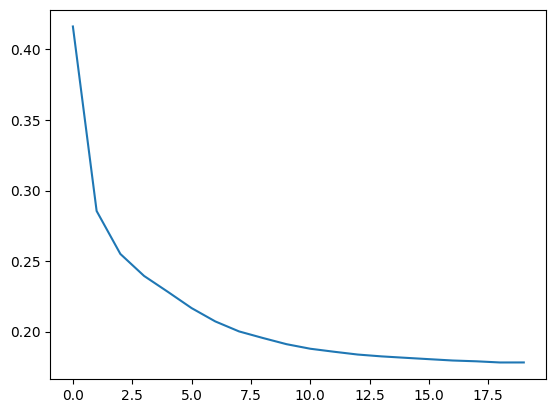

In [40]:
import matplotlib.pyplot as plt

plt.plot(mlp_history)
plt.show()

### Prediction

In [41]:
mlp_test_pred = mlp_model.predict([test_data[:, 0], test_data[:, 1]], batch_size=2048)

ndcg_values = ndcg.average_ndcg(test_data[:, 0], mlp_test_pred, test_data[:, 2], topn, all_users)
hr_values, hits = hr.average_hr(test_data[:, 0], mlp_test_pred, test_data[:, 2], topn, all_users)

print(f"HR: {hr_values}, NDCG: {ndcg_values}")

2695/2695 [==============================] - 3s 1ms/step
HR: 0.8433145487161832, NDCG: 0.5146399420081064


### save weights

In [42]:
# Save the Model
mlp_model.save('../checkpoints/pinterest_mlp_model')

INFO:tensorflow:Assets written to: ../checkpoints/pinterest_mlp_model/assets


# NeuMF (Neural Matrix Factorization)

In [43]:
# pre-trained
def get_neuMF(num_users, num_items, gmf_model, mlp_model, latent_dim, layer_dims):

    # common inputs
    user_input = tf.keras.layers.Input(shape=1, dtype="float32")
    item_input = tf.keras.layers.Input(shape=1, dtype="float32")
    
    # get gmf model
    gmf_user_embedding = gmf_model.get_layer('gmf_user_embedding')(user_input)
    gmf_item_embedding = gmf_model.get_layer('gmf_item_embedding')(item_input)

    gmf_user_flatten = tf.keras.layers.Flatten()(gmf_user_embedding)
    gmf_item_flatten = tf.keras.layers.Flatten()(gmf_item_embedding)

    gmf_multiply = gmf_model.get_layer('multiply')([gmf_user_flatten, gmf_item_flatten])
    # gmf_branch = gmf_model.get_layer('last_layer')(gmf_multiply)

    # get mlp model
    mlp_user_embedding = mlp_model.get_layer('mlp_user_embedding')(user_input)
    mlp_item_embedding = mlp_model.get_layer('mlp_item_embedding')(item_input)

    mlp_user_flatten = tf.keras.layers.Flatten()(mlp_user_embedding)
    mlp_item_flatten = tf.keras.layers.Flatten()(mlp_item_embedding)

    x = mlp_model.get_layer('concatenate')([mlp_user_flatten, mlp_item_flatten])

    # multi layers
    for i, l in enumerate(layer_dims):
        x = mlp_model.get_layer(f'{i}st_layer')(x)
        
    # mlp_branch = mlp_model.get_layer('last_layer')(x)

    # concat branches
    x = tf.keras.layers.Concatenate(name='concatenate2')([gmf_multiply, x])

    # last layer
    neumf_last_layer = tf.keras.layers.Dense(units=1, activation="sigmoid", dtype="float32", name='last_layer',
        kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01, seed=42), bias_constraint=None)(x)

    neumf_model = tf.keras.Model([user_input, item_input], neumf_last_layer)
    return neumf_model

In [44]:
neuMF_model = get_neuMF(len(all_users), len(all_items), 
    gmf_model, mlp_model, embedding_size, [32, 16, 8])

neuMF_model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 input_6 (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 mlp_user_embedding (Embedding)  (None, 1, 8)        441496      ['input_5[0][0]']                
                                                                                                  
 mlp_item_embedding (Embedding)  (None, 1, 8)        79288       ['input_6[0][0]']                
                                                                                            

In [45]:
neuMF_model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate), loss="binary_crossentropy")

## Training

In [46]:
loss = neuMF_model.evaluate([test_data[:, 0], test_data[:, 1]], test_data[:, 2], batch_size=2048, verbose=0)
neuMF_test_pred = neuMF_model.predict([test_data[:, 0], test_data[:, 1]], batch_size=2048, verbose=0)

ndcg_values = ndcg.average_ndcg(test_data[:, 0], neuMF_test_pred, test_data[:, 2], topn, all_users)
hr_values, hits = hr.average_hr(test_data[:, 0], neuMF_test_pred, test_data[:, 2], topn, all_users)

print(f"Init! loss: {loss}, HR: {hr_values}, NDCG: {ndcg_values}")

Init! loss: 0.890618622303009, HR: 0.001993223041658362, NDCG: 0.0008602356978203932


In [47]:
gmf_history = []

for iter_ in range(epochs):
    train_data = prep_train_data(train_positive, num_neg)

    history_ = neuMF_model.fit(
        [train_data[:, 0], train_data[:, 1]], train_data[:, 2], epochs=1, 
        batch_size=batch_size)
    
    gmf_history.append(history_.history['loss'])
    
    loss = neuMF_model.evaluate([test_data[:, 0], test_data[:, 1]], test_data[:, 2], batch_size=2048, verbose=0)
    gmf_test_pred = neuMF_model.predict([test_data[:, 0], test_data[:, 1]], batch_size=2048, verbose=0)

    ndcg_values = ndcg.average_ndcg(test_data[:, 0], gmf_test_pred, test_data[:, 2], topn, all_users)
    hr_values, hits = hr.average_hr(test_data[:, 0], gmf_test_pred, test_data[:, 2], topn, all_users)

    print(f"epoch: {iter_}, loss: {loss}, HR: {hr_values}, NDCG: {ndcg_values}")

28235/28235 [==============================] - 71s 2ms/step - loss: 0.1655
epoch: 0, loss: 0.11228489130735397, HR: 0.8649681990323809, NDCG: 0.5352868149014044
28235/28235 [==============================] - 71s 3ms/step - loss: 0.1619
epoch: 1, loss: 0.11265803873538971, HR: 0.8647145160998061, NDCG: 0.5352100620646089
28235/28235 [==============================] - 73s 3ms/step - loss: 0.1613
epoch: 2, loss: 0.11209555715322495, HR: 0.8651312809176074, NDCG: 0.5354977038209303
28235/28235 [==============================] - 74s 3ms/step - loss: 0.1611
epoch: 3, loss: 0.10990417003631592, HR: 0.8649681990323809, NDCG: 0.5355821661986364
28235/28235 [==============================] - 72s 3ms/step - loss: 0.1607
epoch: 4, loss: 0.10900159925222397, HR: 0.8650225596607897, NDCG: 0.5352717134329072
28235/28235 [==============================] - 75s 3ms/step - loss: 0.1606
epoch: 5, loss: 0.11148906499147415, HR: 0.8650044394513201, NDCG: 0.535315659805388
28235/28235 [======================

In [ ]:
# neuMF_history = neuMF_model.fit([train[:, 0], train[:, 1]], train[:, 2], epochs=150, batch_size=2048)

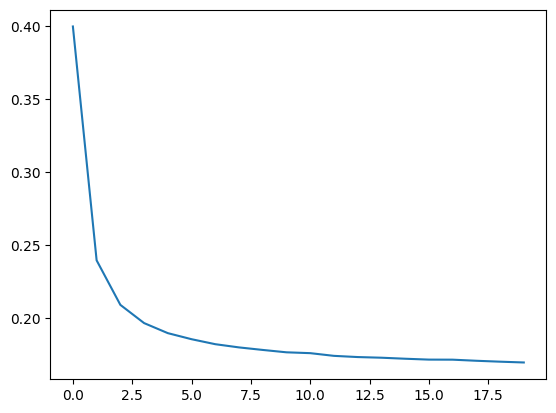

In [38]:
import matplotlib.pyplot as plt

plt.plot(gmf_history)
plt.show()

In [48]:
# neuMF
neuMF_test_pred = neuMF_model.predict([test_data[:, 0], test_data[:, 1]], batch_size=2048)

ndcg_values = ndcg.average_ndcg(test_data[:, 0], neuMF_test_pred, test_data[:, 2], topn, all_users)
hr_values, hits = hr.average_hr(test_data[:, 0], neuMF_test_pred, test_data[:, 2], topn, all_users)

print(f"HR: {hr_values}, NDCG: {ndcg_values}")

2695/2695 [==============================] - 4s 1ms/step
HR: 0.8660372913910884, NDCG: 0.535913973628704


In [49]:
# Save the Model
neuMF_model.save('../checkpoints/pinterest_neuMF_model')

INFO:tensorflow:Assets written to: ../checkpoints/pinterest_neuMF_model/assets


---

In paper
* users: 55187
* items: 9,916
* interactions: 1,500,809

In [10]:
all_pins = set()

for b in board_pins:
    for p in b['pins']:
        all_pins.add(p)

all_pins = list(all_pins)
len(all_pins)

2565241

<!-- # Prepare Train/Test data

- leave-one-out evaluation (positive)
    - 테스트 데이터: 유저의 latest 데이터
    - 학습 데이터: 유저의 나머지 데이터
- 학습 시에는 모든 negative 데이터를 포함
- 평가 시에는 positive test data 하나와 나머지 샘플링한 unobserved 100개 데이터를 합하여 랭킹
- 위 랭킹 결과의 top k에 대해서 positive 가 포함되어 있으면 hit, 그 위치가 어디인지를 NDCG가 측정 -->

In [4]:
all_pins = set()

for b in board_pins:
    for p in b['pins']:
        all_pins.add(p)

all_pins = list(all_pins)
len(all_pins)

2565241

In [5]:
user_set = set([b['board_id'] for b in board_pins])

In [6]:
pins = [len(b['pins']) for b in board_pins]
num_negative = int(sum(pins)/len(pins))
num_negative

55

In [7]:
pin_map = {p:i for i,p in enumerate(all_pins)}
user_map = {u:i for i,u in enumerate(user_set)}

len(pin_map.keys()), len(user_map.keys())

(2565241, 46000)

In [8]:
train = [] # user, item, score
test = [] # user, item, score

for b in tqdm(board_pins):
    train.extend([[user_map[b['board_id']], pin_map[p], 1] for p in b['pins'][:-1]])
    test.append([user_map[b['board_id']], pin_map[b['pins'][-1]], 1])

100%|██████████| 46000/46000 [00:06<00:00, 7162.25it/s] 


In [9]:
def sampling(num_sample, all_pins, without, user_board):
    idx = 0
    sampled = []
    while idx < num_sample:
        randint = np.random.randint(0, 5043)
        if all_pins[randint] in without:
            continue
        else:
            sampled.append([user_map[user_board], pin_map[all_pins[randint]], 0])
            idx += 1
    return sampled

for b in tqdm(board_pins):
    train.extend(sampling(num_negative, all_pins, b['pins'], b['board_id']))
    test.extend(sampling(100, all_pins, b['pins'], b['board_id']))

100%|██████████| 46000/46000 [00:36<00:00, 1265.02it/s]


In [10]:
train, test = np.array(train), np.array(test)
train.shape, test.shape

((5049242, 3), (4646000, 3))

In [11]:
np.random.shuffle(train)
np.random.shuffle(test)

샘플링은 유저별로 55번씩하면 되는데 positive에 있는 데이터가 들어가면 안됨

In [12]:
all_users = {tp[0] for tp in np.concatenate([train,test], axis=0)}
all_items = {tp[1] for tp in np.concatenate([train,test], axis=0)}
len(all_users), len(all_items)

(46000, 2565241)

# GMF (generalization matrix factorization)

## build

In [13]:
def get_gmf(num_users, num_items, latent_dim):
    
    user_input = tf.keras.layers.Input(shape=1, dtype="float32")
    item_input = tf.keras.layers.Input(shape=1, dtype="float32")

    user_embedding = tf.keras.layers.Embedding(input_dim=num_users, output_dim=latent_dim, name='user_embedding',
                    embeddings_initializer='normal', input_length=1)(user_input)
    item_embedding = tf.keras.layers.Embedding(input_dim=num_items, output_dim=latent_dim, name='item_embedding',
                    embeddings_initializer='normal', input_length=1)(item_input)
    
    user_flatten = tf.keras.layers.Flatten()(user_embedding)
    item_flatten = tf.keras.layers.Flatten()(item_embedding)

    x = tf.keras.layers.Lambda(lambda x: tf.multiply(x[0], x[1]))([user_flatten, item_flatten])
    x = tf.keras.layers.Dense(units=1, activation="sigmoid", dtype="float32", name='last_layer',
        kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01, seed=42))(x)

    model = tf.keras.Model([user_input, item_input], x)
    return model

In [14]:
# hyperparams
learning_rate = 0.001


mirrored_strategy = tf.distribute.MirroredStrategy()

with mirrored_strategy.scope():
  gmf_model = get_gmf(len(all_users), len(all_items), 16)

gmf_model.summary()

2023-07-20 07:55:51.301029: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-20 07:55:51.302811: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-20 07:55:51.314126: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-20 07:55:51.315723: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-20 07:55:51.317322: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from S

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 user_embedding (Embedding)     (None, 1, 16)        736000      ['input_1[0][0]']                
                                                                                                  
 item_embedding (Embedding)     (None, 1, 16

In [15]:
gmf_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss="binary_crossentropy")

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


## training

In [16]:
gmf_model.fit([train[:, 0], train[:, 1]], train[:, 2], epochs=10, batch_size=2048)

Epoch 1/10
INFO:tensorflow:batch_all_reduce: 2 all-reduces with algorithm = nccl, num_packs = 1
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1').
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1').
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:batch_all_reduce: 2 all-reduces with algorithm = nccl, num_packs = 1
INFO:tensorflow:Reduce to

## prediction

In [17]:
gmf_test_pred = gmf_model.predict([test[:, 0], test[:, 1]], batch_size=2048)

2269/2269 [==============================] - 8s 3ms/step


## Multi Layer Perceptron

In [ ]:
def get_mlp(num_users, num_items, latent_dim, layer_dims):
    
    user_input = tf.keras.layers.Input(shape=1, dtype="float32")
    item_input = tf.keras.layers.Input(shape=1, dtype="float32")

    user_embedding = tf.keras.layers.Embedding(input_dim=num_users, output_dim=latent_dim, name='user_embedding',
                    embeddings_initializer='normal', input_length=1)(user_input)
    item_embedding = tf.keras.layers.Embedding(input_dim=num_items, output_dim=latent_dim, name='item_embedding',
                    embeddings_initializer='normal', input_length=1)(item_input)
    
    user_flatten = tf.keras.layers.Flatten()(user_embedding)
    item_flatten = tf.keras.layers.Flatten()(item_embedding)

    x = tf.keras.layers.Concatenate()([user_flatten, item_flatten])

    # multi layers
    for i, l in enumerate(layer_dims):
        x = tf.keras.layers.Dense(units=l, activation="relu", dtype="float32", name=f'{i}st_layer',
            kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01, seed=42))(x)

    # last layer
    x = tf.keras.layers.Dense(units=1, activation="sigmoid", dtype="float32", name='last_layer',
        kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01, seed=42))(x)

    model = tf.keras.Model([user_input, item_input], x)
    return model

In [ ]:
mlp_model = get_mlp(len(all_users), len(all_items), 16, [32, 16, 8])
mlp_model.summary()

In [ ]:
learning_rate = 0.00001
mlp_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss="binary_crossentropy", metrics=['acc'])

In [ ]:
mlp_model.fit([train[:, 0], train[:, 1]], train[:, 2], epochs=10, batch_size=2048)

# NeuMF (Neural Matrix Factorization)

In [ ]:
def get_neuMF(num_users, num_items, latent_dim, layer_dims):

    # common inputs
    user_input = tf.keras.layers.Input(shape=1, dtype="float32")
    item_input = tf.keras.layers.Input(shape=1, dtype="float32")

    # gmf branch
    gmf_user_embedding = tf.keras.layers.Embedding(input_dim=num_users, output_dim=latent_dim, name='gmf_user_embedding',
                    embeddings_initializer='normal', input_length=1)(user_input)
    gmf_item_embedding = tf.keras.layers.Embedding(input_dim=num_items, output_dim=latent_dim, name='gmf_item_embedding',
                    embeddings_initializer='normal', input_length=1)(item_input)
    
    gmf_user_flatten = tf.keras.layers.Flatten()(gmf_user_embedding)
    gmf_item_flatten = tf.keras.layers.Flatten()(gmf_item_embedding)

    gmf_multiply = tf.keras.layers.Lambda(lambda x: tf.multiply(x[0], x[1]), name='gmf_multiply')(
        [gmf_user_flatten, gmf_item_flatten])

    # mlp branch
    mlp_user_embedding = tf.keras.layers.Embedding(input_dim=num_users, output_dim=latent_dim, name='mlp_user_embedding',
                    embeddings_initializer='normal', input_length=1)(user_input)
    mlp_item_embedding = tf.keras.layers.Embedding(input_dim=num_items, output_dim=latent_dim, name='mlp_item_embedding',
                    embeddings_initializer='normal', input_length=1)(item_input)
    
    mlp_user_flatten = tf.keras.layers.Flatten()(mlp_user_embedding)
    mlp_item_flatten = tf.keras.layers.Flatten()(mlp_item_embedding)

    x = tf.keras.layers.Concatenate()([mlp_user_flatten, mlp_item_flatten])

    # multi layers
    for i, l in enumerate(layer_dims):
        x = tf.keras.layers.Dense(units=l, activation="relu", dtype="float32", name=f'{i}st_layer',
            kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01, seed=42))(x)
        
    # concat branches
    x = tf.keras.layers.Concatenate()([gmf_multiply, x])

    # last layer
    neumf_last_layer = tf.keras.layers.Dense(units=1, activation="sigmoid", dtype="float32", name='last_layer',
        kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01, seed=42), bias_constraint=None)(x)

    neumf_model = tf.keras.Model([user_input, item_input], neumf_last_layer)


In [ ]:
neuMF_model = get_neuMF(len(all_users), len(all_items), 16, [32, 16, 8])
neuMF_model.summary()

## load saved weights

In [ ]:
learning_rate = 0.00001
neuMF_model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate), loss="binary_crossentropy", metrics=['acc'])

## Training

In [ ]:
neuMF_model.fit([train[:, 0], train[:, 1]], train[:, 2], epochs=10, batch_size=2048)

# Evaluation

## NDCG

In [18]:
gmf_test_pred

array([[3.2802136e-06],
       [4.4711422e-05],
       [3.6975984e-05],
       ...,
       [5.1606380e-06],
       [1.1082555e-07],
       [1.2884149e-06]], dtype=float32)

In [33]:
import imp
import evaluate
imp.reload(evaluate.ndcg)

<module 'evaluate.hr' from '/home/leejuyeon/etc/recsys/models/../evaluate/hr.py'>

In [23]:
import sys
sys.path.insert(0, '..')
from evaluate import ndcg #import average_ndcg

topn = 10
ndcg.average_ndcg(test[:, 0], gmf_test_pred, test[:, 2], topn, len(all_users))

0.9981521739130435

## Hit rate

In [ ]:
imp.reload(evaluate.hr)

In [34]:
from evaluate import hr

hr, hits = hr.average_hr(test[:, 0], gmf_test_pred, test[:, 2], topn, len(all_users))

In [40]:
np.unique(hits, return_counts=True)

(array([0, 1]), array([   85, 45915]))